# 01 - Exploratory Data Analysis: UNSW-NB15

This notebook explores the UNSW-NB15 dataset before modeling:
- Class balance (normal vs. attack, and per attack category)
- Feature distributions
- Correlations
- Categorical feature breakdown (protocol, service, state)

Run `src/generate_sample_data.py` first if you don't have the real dataset yet --
this notebook will automatically fall back to the synthetic sample data.


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_preprocessing import load_raw_data, clean_columns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 60)


In [2]:
train_df, test_df, source = load_raw_data()
train_df = clean_columns(train_df)
test_df = clean_columns(test_df)

print(f"Data source: {source} ('real' = actual UNSW-NB15, 'sample' = synthetic placeholder)")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()


Loading REAL dataset from d:\projects\nids_project\data\raw\UNSW_NB15_training-set.csv
Data source: real ('real' = actual UNSW-NB15, 'sample' = synthetic placeholder)
Train shape: (175341, 45)
Test shape:  (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


## Class balance

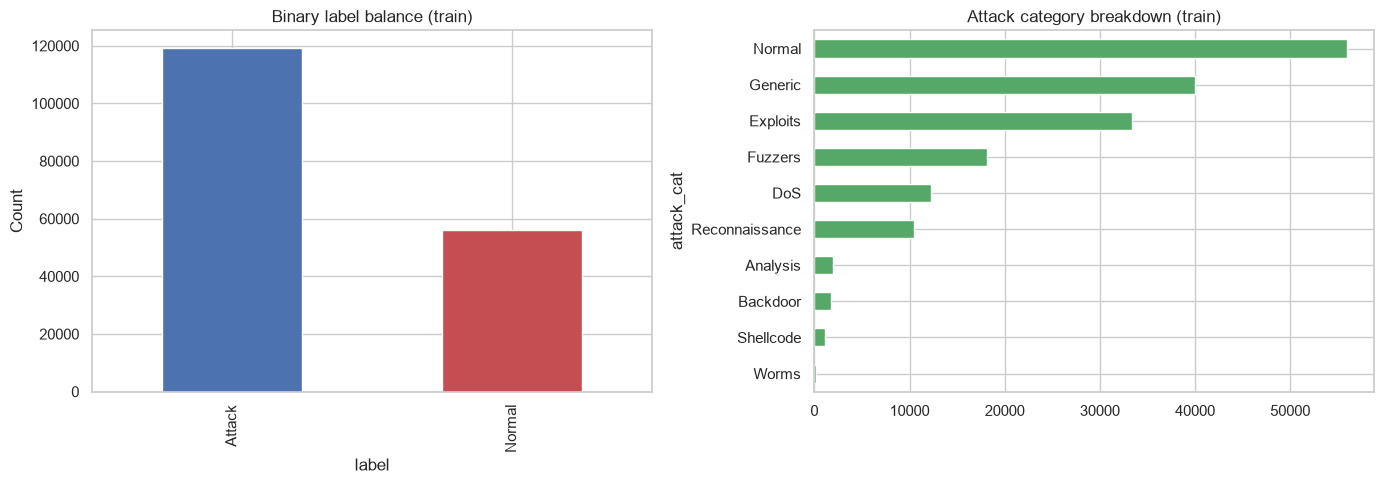

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train_df['label'].map({0: 'Normal', 1: 'Attack'}).value_counts().plot(
    kind='bar', ax=axes[0], color=['#4C72B0', '#C44E52']
)
axes[0].set_title('Binary label balance (train)')
axes[0].set_ylabel('Count')

train_df['attack_cat'].value_counts().plot(kind='barh', ax=axes[1], color='#55A868')
axes[1].set_title('Attack category breakdown (train)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Interpretation:** UNSW-NB15 is imbalanced -- normal traffic and a couple of attack categories (typically Generic, Exploits) dominate, while categories like Worms and Shellcode have very few samples. Note this explicitly in your report -- it's why precision/recall/F1 matter more than raw accuracy, and it's a legitimate reason to consider techniques like class weighting or SMOTE.

## Categorical features: protocol, service, state

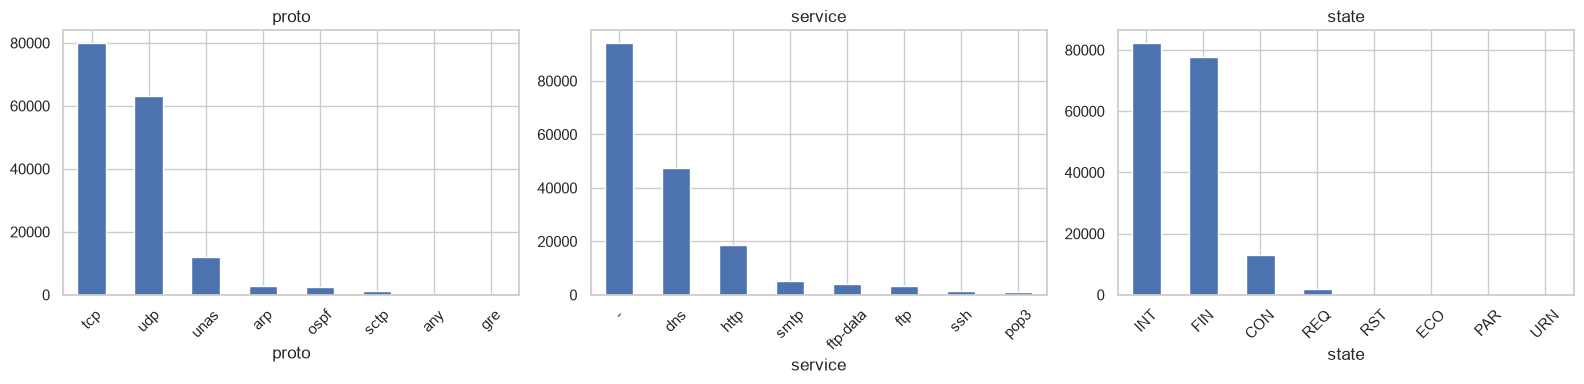

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['proto', 'service', 'state']):
    train_df[col].value_counts().head(8).plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Numeric feature distributions

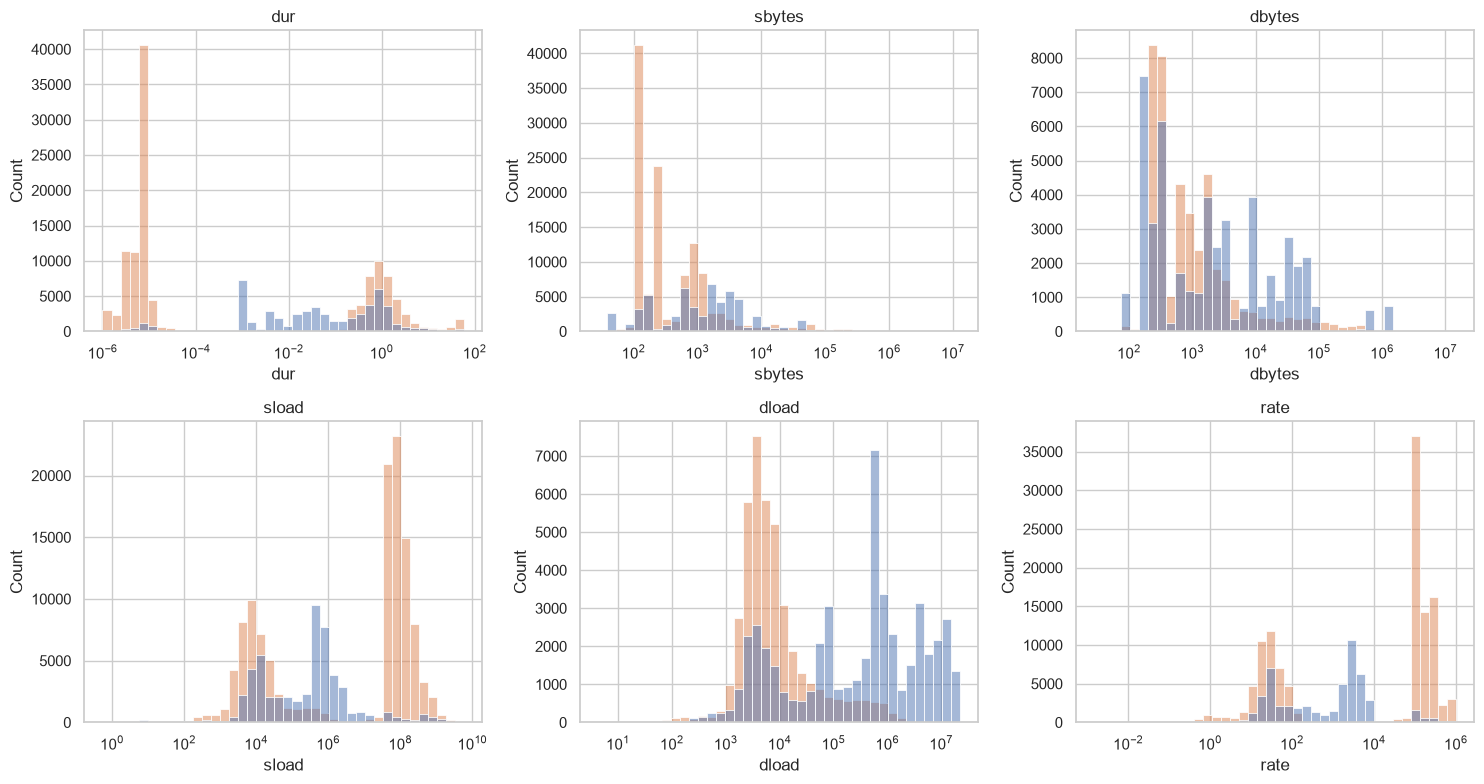

In [5]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
numeric_cols = [c for c in numeric_cols if c not in ('id', 'label')]

sample_cols = ['dur', 'sbytes', 'dbytes', 'sload', 'dload', 'rate']
sample_cols = [c for c in sample_cols if c in numeric_cols]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), sample_cols):
    sns.histplot(train_df, x=col, hue='label', bins=40, log_scale=(True, False), ax=ax, legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


**Interpretation:** most byte/rate/load features are heavily right-skewed (a log x-axis is used above to make this visible) -- this is why StandardScaler normalization matters before feeding these into SVM/MLP, which are sensitive to feature scale (tree-based models like Random Forest/XGBoost are not, but we scale uniformly for consistency).

## Correlation heatmap (numeric features)

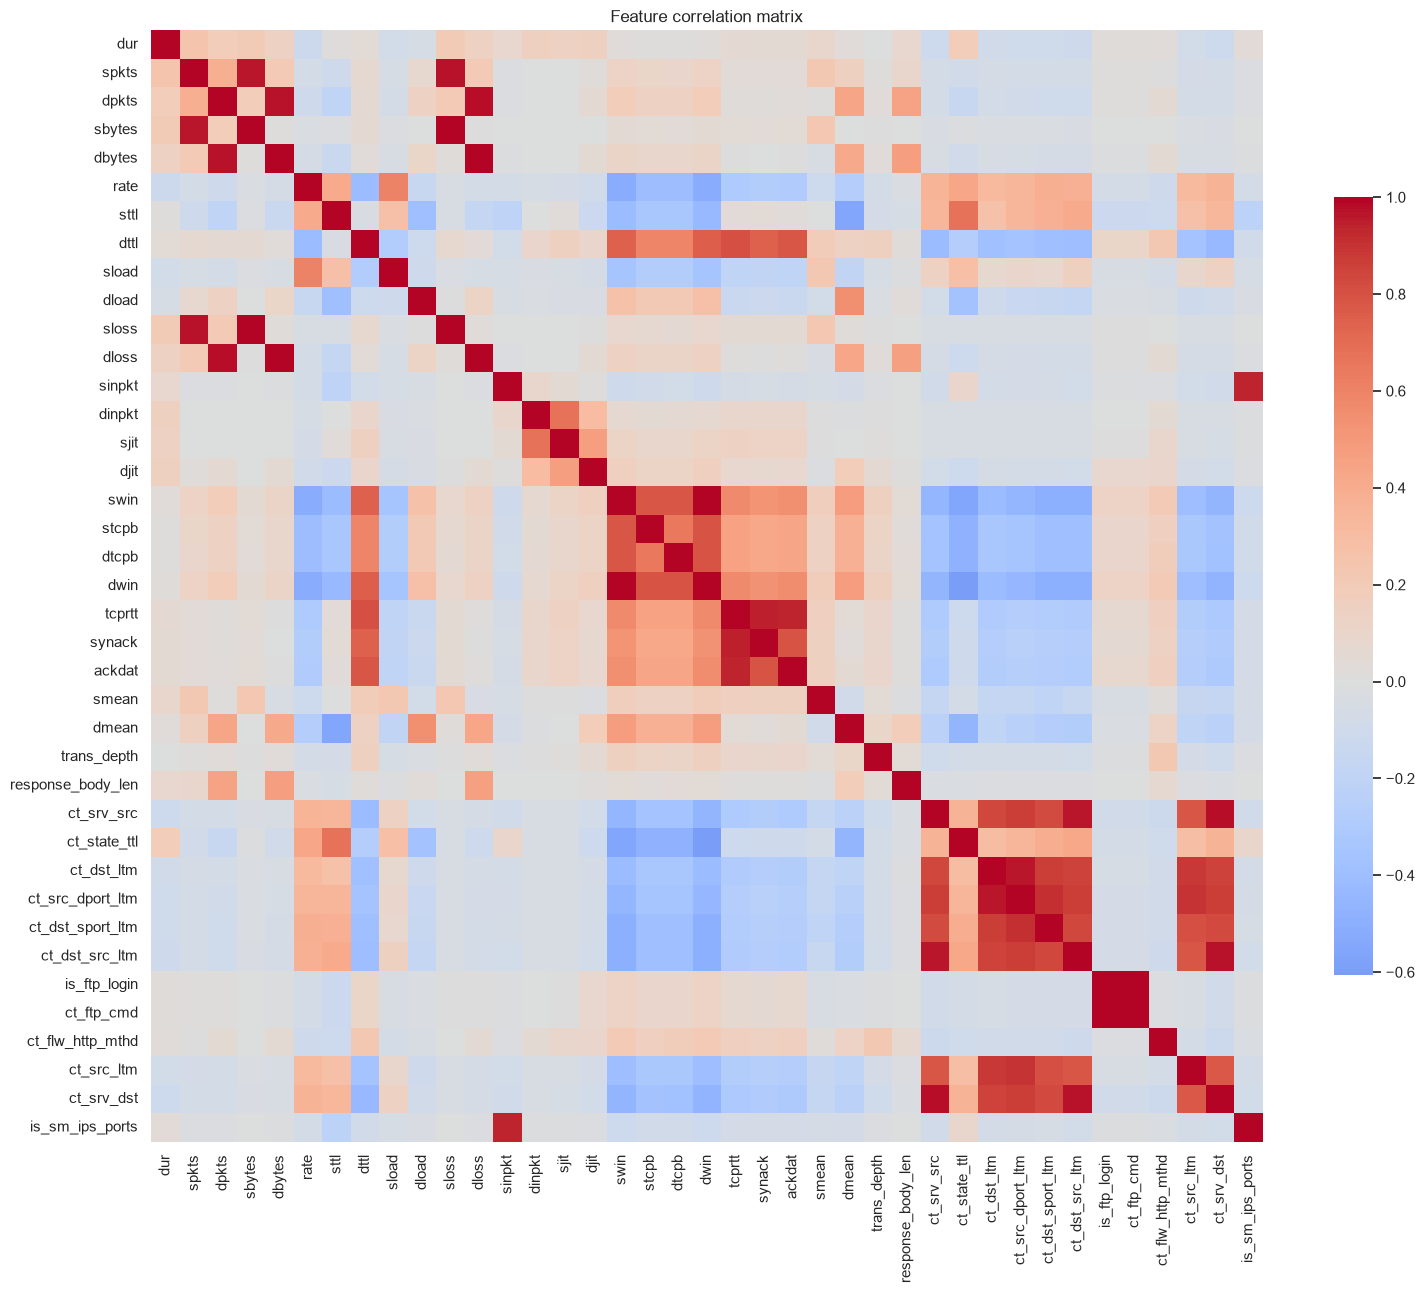

In [6]:
corr = train_df[numeric_cols].corr()
plt.figure(figsize=(16, 13))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()


**Interpretation:** look for clusters of highly correlated features (e.g. `sload`/`sbytes`, `spkts`/`dpkts` families) -- these are candidates for dimensionality reduction or feature selection if your report wants to discuss reducing model complexity without losing accuracy.

## Next step

Open `02_modeling_explainability.ipynb` to train models and generate SHAP/LIME explanations.